In [1]:
#1: Import libraries
!pip install -q imbalanced-learn joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import joblib

RANDOM_STATE = 42


In [2]:
#2: Load the cleaned insider threat dataset
df = pd.read_csv("/content/drive/MyDrive/AppliedResearchProj_Dataset/Coding_Dataset/AppliedResearchDataset_cleanVer1.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nTarget distribution (is_insider):")
print(df["is_insider"].value_counts())
print("\nTarget distribution (normalised):")
print(df["is_insider"].value_counts(normalize=True))


Shape: (12000, 15)

First 5 rows:


,is_insider,id,user,pc,event_src,activity,date,to_removable_media,from_removable_media,size,Openness score,Conscientiousness score,Extraversion score,Agreeableness score,Neuroticism score
0,True,{T2N6-X9QL06RX-0762MGAR},CSC0217,PC-5391,logon,Logon,6/10/2010 0:00,False,False,0,40,15,30,38,28
1,True,{H5W6-B8OS58UZ-7808LFON},CSC0217,PC-6377,logon,Logon,6/11/2010 0:00,False,False,0,40,15,30,38,28
2,True,{J4H8-U4HY76KF-8654QSST},CSC0217,PC-6377,logon,Logon,6/11/2010 0:00,False,False,0,40,15,30,38,28
3,True,{K7J1-R9NA31CC-0202USEF},CSC0217,PC-5391,logon,Logoff,6/10/2010 0:00,False,False,0,40,15,30,38,28
4,True,{E6S3-A8MW97SQ-7179CYTE},CSC0217,PC-9873,logon,Logoff,6/10/2010 0:00,False,False,0,40,15,30,38,28



Target distribution (is_insider):
is_insider
True     6000
False    6000
Name: count, dtype: int64

Target distribution (normalised):
is_insider
True     0.5
False    0.5
Name: proportion, dtype: float64


In [3]:
#3: Define X, y and feature groups (after removing data leakage columns)

# Convert target to int
df["is_insider"] = df["is_insider"].astype(int)

# Drop ID + leakage columns + identity columns (user, pc)
df_model = df.drop(columns=[
    "id",
    "event_src",          # leakage: monitoring source
    "date",               # leakage: time window
    "user",               # identity, too close to label
    "pc"                  # machine ID, too close to label
])

X = df_model.drop(columns=["is_insider"])
y = df_model["is_insider"]

numeric_features = [
    "size",
    "Openness score ",
    "Conscientiousness score",
    "Extraversion score",
    "Agreeableness score",
    "Neuroticism score"
]

categorical_features = [
    "activity",
    "to_removable_media",
    "from_removable_media"
]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)


Numeric: ['size', 'Openness score ', 'Conscientiousness score', 'Extraversion score', 'Agreeableness score', 'Neuroticism score']
Categorical: ['activity', 'to_removable_media', 'from_removable_media']
Train: (9600, 9)  Test: (2400, 9)


In [4]:
#4: Build preprocessing pipeline

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print(preprocessor)


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['size', 'Openness score ',
                                  'Conscientiousness score',
                                  'Extraversion score', 'Agreeableness score',
                                  'Neuroticism score']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['activity', 'to_removable_media',
                                  'from_removable_media'])])


In [5]:
#5: Shared evaluation function for all models

results = {}   # dictionary to store metrics

def evaluate_and_store(name, y_true, y_pred, y_proba):
    acc  = accuracy_score(y_true, y_pred)
    ce   = 1 - acc
    auc  = roc_auc_score(y_true, y_proba)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    print(f"\n{name} – Test Metrics")
    print(f"Accuracy           : {acc:.4f}")
    print(f"Classification Err.: {ce:.4f}")
    print(f"ROC-AUC            : {auc:.4f}")
    print(f"Precision          : {prec:.4f}")
    print(f"Recall             : {rec:.4f}")
    print(f"F1-score           : {f1:.4f}\n")

    print("Classification report:\n")
    print(classification_report(
        y_true, y_pred,
        target_names=["Outsider (0)", "Insider (1)"]
    ))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    results[name] = {
        "accuracy": acc,
        "classification_error": ce,
        "AUC": auc,
        "precision": prec,
        "recall": rec,
        "F1": f1
    }



Logit – Test Metrics
Accuracy           : 0.9546
Classification Err.: 0.0454
ROC-AUC            : 0.9911
Precision          : 0.9389
Recall             : 0.9725
F1-score           : 0.9554

Classification report:

              precision    recall  f1-score   support

Outsider (0)       0.97      0.94      0.95      1200
 Insider (1)       0.94      0.97      0.96      1200

    accuracy                           0.95      2400
   macro avg       0.96      0.95      0.95      2400
weighted avg       0.96      0.95      0.95      2400



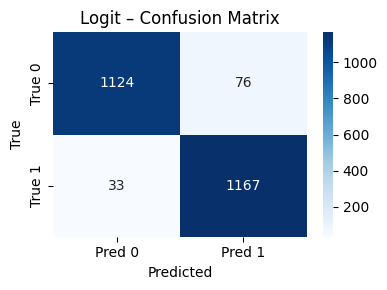

['insider_logreg_baseline.pkl']

In [6]:
#6: Logistic Regression (Logit)

log_reg_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

log_reg_clf.fit(X_train, y_train)

y_pred_lr  = log_reg_clf.predict(X_test)
y_proba_lr = log_reg_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("Logit", y_test, y_pred_lr, y_proba_lr)

# Save model
joblib.dump(log_reg_clf, "insider_logreg_baseline.pkl")



RF – Test Metrics
Accuracy           : 0.9967
Classification Err.: 0.0033
ROC-AUC            : 1.0000
Precision          : 0.9934
Recall             : 1.0000
F1-score           : 0.9967

Classification report:

              precision    recall  f1-score   support

Outsider (0)       1.00      0.99      1.00      1200
 Insider (1)       0.99      1.00      1.00      1200

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



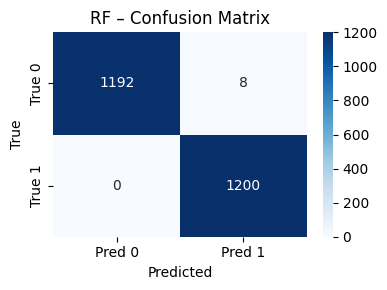

['insider_random_forest.pkl']

In [7]:
#7: Random Forest (RF)

rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_clf.fit(X_train, y_train)

y_pred_rf  = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("RF", y_test, y_pred_rf, y_proba_rf)

# Save model
joblib.dump(rf_clf, "insider_random_forest.pkl")



SVM – Test Metrics
Accuracy           : 0.9846
Classification Err.: 0.0154
ROC-AUC            : 0.9964
Precision          : 0.9724
Recall             : 0.9975
F1-score           : 0.9848

Classification report:

              precision    recall  f1-score   support

Outsider (0)       1.00      0.97      0.98      1200
 Insider (1)       0.97      1.00      0.98      1200

    accuracy                           0.98      2400
   macro avg       0.98      0.98      0.98      2400
weighted avg       0.98      0.98      0.98      2400



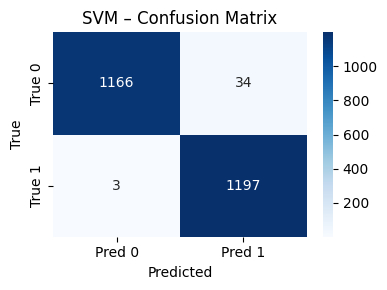

In [8]:
#8: SVM (RBF)

from sklearn.svm import SVC

svm_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

svm_clf.fit(X_train, y_train)

y_pred_svm  = svm_clf.predict(X_test)
y_proba_svm = svm_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("SVM", y_test, y_pred_svm, y_proba_svm)



GBT – Test Metrics
Accuracy           : 0.9967
Classification Err.: 0.0033
ROC-AUC            : 1.0000
Precision          : 0.9934
Recall             : 1.0000
F1-score           : 0.9967

Classification report:

              precision    recall  f1-score   support

Outsider (0)       1.00      0.99      1.00      1200
 Insider (1)       0.99      1.00      1.00      1200

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



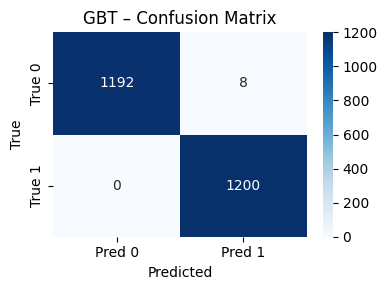

In [9]:
#9: XGBoost (GBT)

!pip install -q xgboost
from xgboost import XGBClassifier

xgb_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_clf.fit(X_train, y_train)

y_pred_xgb  = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("GBT", y_test, y_pred_xgb, y_proba_xgb)


Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8070 - loss: 0.4429 - val_accuracy: 0.9536 - val_loss: 0.1003
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9624 - loss: 0.1010 - val_accuracy: 0.9568 - val_loss: 0.0900
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9704 - loss: 0.0820 - val_accuracy: 0.9724 - val_loss: 0.0703
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9744 - loss: 0.0775 - val_accuracy: 0.9688 - val_loss: 0.0716
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9742 - loss: 0.0708 - val_accuracy: 0.9708 - val_loss: 0.0675
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9746 - loss: 0.0763 - val_accuracy: 0.9729 - val_loss: 0.0649
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9773 - loss: 0.0606 - val_accuracy: 0.9812 - val_loss: 0.0591
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9776 - loss: 0.0624 - val_accuracy: 0.

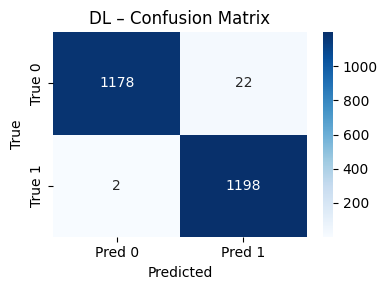

['insider_preprocessor_for_dl.pkl']

In [10]:
#10: Deep Learning model (DL – Feed-forward NN)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Fit preprocessor on train data only
preprocessor_dl = preprocessor.fit(X_train)

X_train_dl = preprocessor_dl.transform(X_train)
X_test_dl  = preprocessor_dl.transform(X_test)

# Convert to dense if sparse
if hasattr(X_train_dl, "toarray"):
    X_train_dl = X_train_dl.toarray()
    X_test_dl  = X_test_dl.toarray()

input_dim = X_train_dl.shape[1]

model_dl = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_dl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

es = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model_dl.fit(
    X_train_dl, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[es],
    verbose=1
)

# Evaluate on test set
y_proba_dl = model_dl.predict(X_test_dl).ravel()
y_pred_dl  = (y_proba_dl >= 0.5).astype(int)

evaluate_and_store("DL", y_test, y_pred_dl, y_proba_dl)

model_dl.save("insider_deep_nn.h5")
joblib.dump(preprocessor_dl, "insider_preprocessor_for_dl.pkl")


Insider Threat – Model Benchmark


,accuracy,classification_error,AUC,precision,recall,F1
Logit,0.9546,0.0454,0.9911,0.9389,0.9725,0.9554
RF,0.9967,0.0033,1.0000,0.9934,1.0000,0.9967
SVM,0.9846,0.0154,0.9964,0.9724,0.9975,0.9848
GBT,0.9967,0.0033,1.0000,0.9934,1.0000,0.9967
DL,0.9900,0.0100,0.9990,0.9820,0.9983,0.9901


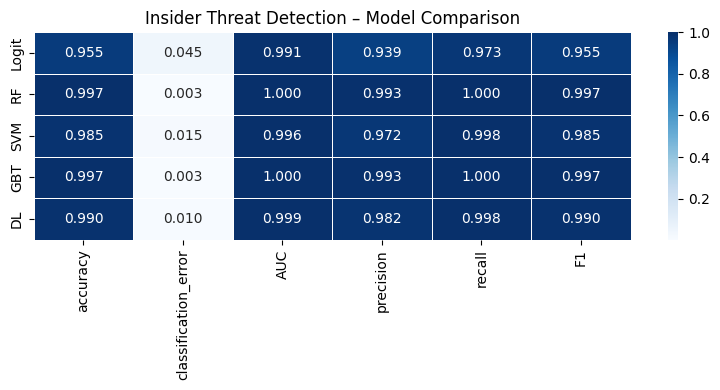

In [11]:
#11: Final model comparison (matches benchmark spreadsheet idea)

df_results = pd.DataFrame(results).T
df_results = df_results[["accuracy", "classification_error", "AUC",
                         "precision", "recall", "F1"]].round(4)

print("Insider Threat – Model Benchmark")
display(df_results)

plt.figure(figsize=(8,4))
sns.heatmap(df_results.astype(float), annot=True, fmt=".3f",
            cmap="Blues", cbar=True, linewidths=.5)
plt.title("Insider Threat Detection – Model Comparison")
plt.tight_layout()
plt.show()


In [30]:
# 1) Go to your repo folder in Colab
%cd /content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation

# 2) Make sure we are using the clean remote URL (no token in it)
!git remote set-url origin https://github.com/egyinmoe/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation.git

# 3) Reset local repo to match GitHub main (this removes the BAD commit with the token)
!git fetch origin
!git reset --hard origin/main


/content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation
HEAD is now at 45bdb94 Update README.md


In [31]:
# 4) Copy the UPDATED notebook (the one you just edited in Colab Drive)
#    Make sure this path is correct – this is where your notebook lives
!cp "/content/drive/MyDrive/Colab Notebooks/Ver2_Insiderthreat_withgithub.ipynb" \
    /content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation/

# 5) Check files in the repo folder
!ls -al


total 280
drwxr-xr-x 3 root root   4096 Nov 18 17:54 .
drwxr-xr-x 1 root root   4096 Nov 18 17:38 ..
drwxr-xr-x 8 root root   4096 Nov 18 17:54 .git
-rw-r--r-- 1 root root   3483 Nov 18 17:38 README.md
-rw-r--r-- 1 root root 270055 Nov 18 17:54 Ver2_Insiderthreat_withgithub.ipynb


In [32]:
# 6) Configure the Git identity (only needed once per Colab session)

!git config --global user.email "eingyinmoe19@gmail.com"
!git config --global user.name "Ein Gyin Moe"

# (OPTIONAL) Check it:
!git config --global user.email
!git config --global user.name


eingyinmoe19@gmail.com
Ein Gyin Moe


In [33]:
# 7) Stage the updated notebook
!git add Ver2_Insiderthreat_withgithub.ipynb

# 8) See what will be committed
!git status


On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   Ver2_Insiderthreat_withgithub.ipynb



In [34]:
# 9) Commit the changes
!git commit -m "Update insider threat modelling (drop leakage, add SVM/XGBoost/DL)"


[main a2a1d01] Update insider threat modelling (drop leakage, add SVM/XGBoost/DL)
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite Ver2_Insiderthreat_withgithub.ipynb (92%)


In [ ]:
# 10) Push to GitHub WITHOUT putting the token in the notebook
#     This should ask you in the output:
#     Username for 'https://github.com':  <type your GitHub username>
#     Password for 'https://github.com':  <type your NEW personal access token>
!git push origin main

In [13]:
!git clone https://github.com/egyinmoe/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation.git


Cloning into 'Detecting-Insider-Threats-through-Behavioral-AI_Dissertation'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 9 (delta 1), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 82.62 KiB | 1.40 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [14]:
%cd Detecting-Insider-Threats-through-Behavioral-AI_Dissertation


/content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation


In [15]:
!git status


On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [16]:
!ls -al /content


total 2720
drwxr-xr-x 1 root root    4096 Nov 18 17:38 .
drwxr-xr-x 1 root root    4096 Nov 18 17:31 ..
drwxr-xr-x 4 root root    4096 Nov 17 14:29 .config
drwxr-xr-x 3 root root    4096 Nov 18 17:38 Detecting-Insider-Threats-through-Behavioral-AI_Dissertation
drwx------ 5 root root    4096 Nov 18 17:33 drive
-rw-r--r-- 1 root root  158664 Nov 18 17:37 insider_deep_nn.h5
-rw-r--r-- 1 root root    4129 Nov 18 17:35 insider_logreg_baseline.pkl
-rw-r--r-- 1 root root    3284 Nov 18 17:37 insider_preprocessor_for_dl.pkl
-rw-r--r-- 1 root root 2587474 Nov 18 17:35 insider_random_forest.pkl
drwxr-xr-x 1 root root    4096 Nov 17 14:29 sample_data


In [17]:
!find / -name "*.ipynb" 2>/dev/null


/root/.julia/packages/GR/TPhYU/examples/faster-time-to-first-plot.ipynb
/root/.julia/packages/GR/TPhYU/examples/anim.ipynb
/root/.julia/packages/GR/TPhYU/examples/line_plot.ipynb
/root/.julia/packages/GR/TPhYU/examples/clifford_attractor.ipynb
/root/.julia/packages/GR/TPhYU/examples/covid19.ipynb
/root/.julia/packages/Interpolations/dR5oF/doc/Plotting examples.ipynb
/root/.julia/packages/Interpolations/dR5oF/doc/Interpolations.jl.ipynb
/usr/local/lib/python3.12/dist-packages/nbclassic/bundler/tests/resources/empty.ipynb
/usr/local/lib/python3.12/dist-packages/notebook/bundler/tests/resources/empty.ipynb
/usr/local/lib/python3.12/dist-packages/panel/tests/ui/io/app.ipynb
/usr/local/lib/python3.12/dist-packages/flax/core/flax_functional_engine.ipynb
/usr/local/lib/python3.12/dist-packages/cuml/experimental/hyperparams/HPO_demo.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/user_guide/13-Custom_Interactivity.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/example

In [18]:
!cp "/content/drive/MyDrive/Colab Notebooks/Ver2_Insiderthreat_withgithub.ipynb" \
    /content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation/


In [19]:
!ls -al /content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation/


total 284
drwxr-xr-x 3 root root   4096 Nov 18 17:38 .
drwxr-xr-x 1 root root   4096 Nov 18 17:38 ..
drwxr-xr-x 8 root root   4096 Nov 18 17:38 .git
-rw-r--r-- 1 root root   3483 Nov 18 17:38 README.md
-rw-r--r-- 1 root root 272332 Nov 18 17:38 Ver2_Insiderthreat_withgithub.ipynb


In [20]:
%cd /content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation


/content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation


In [21]:
!git status


On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Ver2_Insiderthreat_withgithub.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [22]:
!git add Ver2_Insiderthreat_withgithub.ipynb


In [24]:
%cd /content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation


/content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation


In [25]:
!git config --global user.email "eingyinmoe19@gmail.com"
!git config --global user.name "Ein Gyin Moe"


In [26]:
!git config --global user.email
!git config --global user.name


eingyinmoe19@gmail.com
Ein Gyin Moe


In [27]:
!git commit -m "Add additional models and remove user/pc leakage"


[main aeace26] Add additional models and remove user/pc leakage
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite Ver2_Insiderthreat_withgithub.ipynb (92%)
